
# Immo Predictor : Valorisation et Diagnostic Intelligent

## Objectifs
1. **Régression** → Prédire `SalePrice`
2. **Classification** → Prédire `BldgType`

Dataset : House Prices (Kaggle)


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    f1_score,
    confusion_matrix
)

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings("ignore")


## 📌 Chargement des données

In [2]:

df = pd.read_csv("train.csv")  
df.head()


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 🔎 Analyse Exploratoire des Données

In [3]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

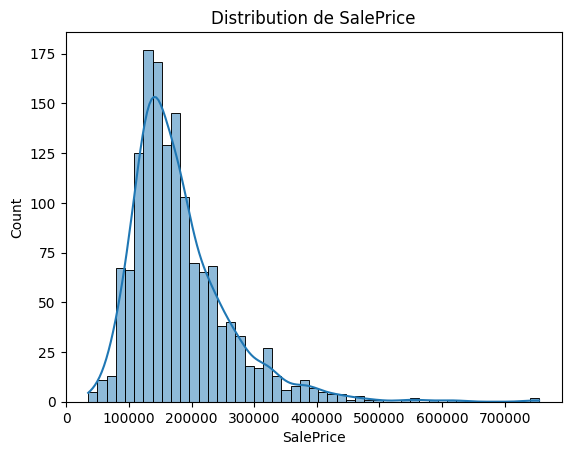

In [4]:

plt.figure()
sns.histplot(df["SalePrice"], kde=True)
plt.title("Distribution de SalePrice")
plt.show()


## 🔵 PARTIE 1 : Régression

In [5]:

reg_features = [
'GrLivArea','TotalBsmtSF','LotArea','BedroomAbvGr',
'FullBath','TotRmsAbvGrd','OverallQual','OverallCond',
'YearBuilt','YearRemodAdd','Neighborhood',
'GarageCars','GarageArea','PoolArea','Fireplaces'
]

X_reg = df[reg_features].fillna(0)
X_reg = pd.get_dummies(X_reg, drop_first=True)
y_reg = df["SalePrice"]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)


In [6]:

# Decision Tree
dt_reg = DecisionTreeRegressor(random_state=42)
dt_reg.fit(X_train_reg, y_train_reg)
y_pred_dt = dt_reg.predict(X_test_reg)

print("Decision Tree")
print("MAE:", mean_absolute_error(y_test_reg, y_pred_dt))
print("RMSE:", np.sqrt(mean_squared_error(y_test_reg, y_pred_dt)))
print("R2:", r2_score(y_test_reg, y_pred_dt))


Decision Tree
MAE: 24784.736301369863
RMSE: 37565.32665762186
R2: 0.8160242825694194


In [7]:

# Random Forest
rf_reg = RandomForestRegressor(n_estimators=200, random_state=42)
rf_reg.fit(X_train_reg, y_train_reg)
y_pred_rf = rf_reg.predict(X_test_reg)

print("Random Forest")
print("MAE:", mean_absolute_error(y_test_reg, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test_reg, y_pred_rf)))
print("R2:", r2_score(y_test_reg, y_pred_rf))


Random Forest
MAE: 17965.556545988256
RMSE: 30077.405315704484
R2: 0.8820584306209158


## 🔴 PARTIE 2 : Classification

In [8]:

clf_features = [
'GrLivArea','TotRmsAbvGrd','OverallQual',
'YearBuilt','GarageCars','Neighborhood','HouseStyle'
]

X_clf = df[clf_features].fillna("Unknown")
X_clf = pd.get_dummies(X_clf, drop_first=True)
y_clf = df["BldgType"]

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_clf = scaler.fit_transform(X_train_clf)
X_test_clf = scaler.transform(X_test_clf)


In [9]:

# SVM
svm = SVC()
svm.fit(X_train_clf, y_train_clf)
y_pred_svm = svm.predict(X_test_clf)

print("SVM")
print("Accuracy:", accuracy_score(y_test_clf, y_pred_svm))
print("F1-score:", f1_score(y_test_clf, y_pred_svm, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_test_clf, y_pred_svm))


SVM
Accuracy: 0.8698630136986302
F1-score: 0.8376317679161808
Confusion Matrix:
 [[240   0   0   0   2]
 [  2   0   0   0   0]
 [ 11   0   0   0   0]
 [  2   0   0   4   5]
 [ 14   0   0   2  10]]


In [10]:

# Random Forest Classifier
rf_clf = RandomForestClassifier(n_estimators=200, random_state=42)
rf_clf.fit(X_train_clf, y_train_clf)
y_pred_rf_clf = rf_clf.predict(X_test_clf)

print("Random Forest Classifier")
print("Accuracy:", accuracy_score(y_test_clf, y_pred_rf_clf))
print("F1-score:", f1_score(y_test_clf, y_pred_rf_clf, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_test_clf, y_pred_rf_clf))


Random Forest Classifier
Accuracy: 0.9246575342465754
F1-score: 0.918067524369968
Confusion Matrix:
 [[239   0   1   0   2]
 [  2   0   0   0   0]
 [  4   0   7   0   0]
 [  2   0   0   7   2]
 [  5   0   0   4  17]]
